# Projeto Guiado — Parte 2 (Semana 15)
### Construção, comparação e escolha do melhor modelo — InPlayGuru (minuto 60)

## 1. Introdução

**Problema:** prever, usando estatísticas do jogo até o minuto 60, se a partida termina com mais de 2.5 gols (`y_over25`).

**Recapitulando a Semana 14:**
| Etapa | O que foi feito |
|---|---|
| Dataset | InPlayGuru — alertas no minuto 60 de jogos europeus |
| EDA | Distribuições, nulos, correlação entre estatísticas ofensivas, insights |
| Pré-processamento | Imputação por mediana, `StandardScaler`, one-hot (Region), frequency encoding (League) |
| Baseline | Regressão Logística |

**Objetivo desta Parte 2:** treinar vários modelos, comparar com métricas apropriadas, escolher o melhor, otimizar com `GridSearchCV` e fechar a documentação do projeto.

## 0. Instalando dependências

In [1]:
!pip install -q scikit-learn xgboost openpyxl matplotlib seaborn pandas numpy

## 1. Subindo os dados
Mesmo arquivo da Parte 1: `InPlayGuru_Europa_minuto_60.xlsx`.

In [2]:
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import files
    print("Selecione o arquivo InPlayGuru_Europa_minuto_60.xlsx")
    uploaded = files.upload()
    FILE_PATH = list(uploaded.keys())[0]
else:
    FILE_PATH = "InPlayGuru_Europa_minuto_60.xlsx"

print("Arquivo usado:", FILE_PATH)


Selecione o arquivo InPlayGuru_Europa_minuto_60.xlsx


Saving InPlayGuru_Europa minuto 60.xlsx to InPlayGuru_Europa minuto 60.xlsx
Arquivo usado: InPlayGuru_Europa minuto 60.xlsx


## 2. Imports

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (7, 5)
sns.set_style("whitegrid")


## 3. Recarregar e preparar os dados
Mesmo pipeline de pré-processamento da Parte 1 (EDA já foi feita lá, não vamos repetir aqui — só o necessário para reconstruir as features).

In [4]:
df = pd.read_excel(FILE_PATH, header=1)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print("Linhas:", len(df), "| Colunas:", df.shape[1])
df.head(3)


Linhas: 55346 | Colunas: 119


,Date,Timer,Strike,Region,League,Home,Away,Home Pos,Away Pos,H Score,A Score,H Momentum,A Momentum,H xG,A xG,H SOT,A SOT,H SOFF,A SOFF,H Corners,A Corners,H Attacks,A Attacks,H Dn Attacks,A Dn Attacks,H Poss %,A Poss %,H Y Cards,A Y Cards,H R Cards,A R Cards,H Penalties,A Penalties,H Score.1,A Score.1,H Momentum.1,A Momentum.1,H xG.1,A xG.1,H SOT.1,A SOT.1,H SOFF.1,A SOFF.1,H Corners.1,A Corners.1,H Attacks.1,A Attacks.1,H Dn Attacks.1,A Dn Attacks.1,H Poss %.1,A Poss %.1,H Y Cards.1,A Y Cards.1,H R Cards.1,A R Cards.1,H Penalties.1,A Penalties.1,H Score.2,A Score.2,H Momentum.2,A Momentum.2,H xG.2,A xG.2,H SOT.2,A SOT.2,H SOFF.2,A SOFF.2,H Corners.2,A Corners.2,H Attacks.2,A Attacks.2,H Dn Attacks.2,A Dn Attacks.2,H Poss %.2,A Poss %.2,H Y Cards.2,A Y Cards.2,H R Cards.2,A R Cards.2,H Penalties.2,A Penalties.2,3-Way: Home,3-Way: Draw,3-Way: Away,Over 0.5 Goals,Under 0.5 Goals,Over 1.5 Goals,Under 1.5 Goals,Over 2.5 Goals,Under 2.5 Goals,Over 3.5 Goals,Under 3.5 Goals,Over 4.5 Goals,Under 4.5 Goals,BTTS: Yes,BTTS: No,3-Way: Home.1,3-Way: Draw.1,3-Way: Away.1,Over 0.5 Goals.1,Under 0.5 Goals.1,Over 1.5 Goals.1,Under 1.5 Goals.1,Over 2.5 Goals.1,Under 2.5 Goals.1,Over 3.5 Goals.1,Under 3.5 Goals.1,Over 4.5 Goals.1,Under 4.5 Goals.1,BTTS: Yes.1,BTTS: No.1,Home.1,Away.1,Score,HT Score,FT Score,Corners,HT Corners,FT Corners
0,2023-03-04 19:15:53,60,NaN,France,France Ligue 2,Annecy,Metz,10.0,4.0,0,2,57.0,13.0,NaN,NaN,2.0,4.0,3.0,6.0,5,2,68.0,53.0,37.0,23.0,57.0,43.0,0,1,0,0,0,0,0.0,1.0,41.0,37.0,NaN,NaN,1.0,3.0,2.0,5.0,2.0,2.0,50.0,44.0,22.0,19.0,56.0,44.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,32.0,30.0,NaN,NaN,3.0,5.0,5.0,9.0,6.0,4.0,91.0,83.0,51.0,48.0,52.0,48.0,1.0,1.0,0.0,0.0,0.0,0.0,41.000,15.000,1.036,NaN,NaN,NaN,NaN,1.444,2.625,3.250,1.333,8.000,1.083,2.375,1.533,3.750,3.1,2.10,1.071,9.0,1.363,3.00,2.20,1.650,3.750,1.25,9.0,1.071,1.909,1.800,NaN,"26, 50, 82",0-2,0-1,0-3,5-2,2-2,6-4
1,2023-03-04 19:16:02,60,NaN,France,France Ligue 2,SC Bastia,Nimes,8.0,18.0,2,2,24.0,26.0,NaN,NaN,4.0,5.0,7.0,2.0,1,1,85.0,73.0,40.0,23.0,59.0,41.0,2,1,0,0,0,0,2.0,1.0,23.0,17.0,NaN,NaN,4.0,3.0,6.0,1.0,0.0,0.0,65.0,61.0,33.0,16.0,57.0,43.0,2.0,1.0,0.0,0.0,0.0,0.0,4.0,2.0,48.0,20.0,NaN,NaN,8.0,5.0,11.0,4.0,2.0,1.0,124.0,108.0,66.0,34.0,61.0,39.0,3.0,2.0,0.0,0.0,1.0,0.0,2.625,1.952,5.500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.571,2.250,1.300,3.400,1.833,3.2,4.75,1.083,8.0,1.400,2.75,2.35,1.571,4.333,1.20,10.0,1.062,2.100,1.666,"27, 35, 73, 87","10, 50",2-2,2-1,4-2,1-1,0-0,2-1
2,2023-03-04 19:16:48,60,NaN,France,France Ligue 2,Niort,Rodez Aveyron,19.0,20.0,1,2,15.0,15.0,NaN,NaN,1.0,2.0,2.0,2.0,0,3,64.0,53.0,26.0,25.0,54.0,46.0,0,1,0,0,0,1,1.0,2.0,21.0,17.0,NaN,NaN,1.0,2.0,1.0,1.0,0.0,3.0,51.0,39.0,23.0,18.0,55.0,45.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,3.0,25.0,27.0,NaN,NaN,2.0,3.0,4.0,2.0,6.0,3.0,97.0,79.0,43.0,38.0,57.0,43.0,0.0,3.0,0.0,0.0,0.0,1.0,10.000,3.750,1.444,NaN,NaN,NaN,NaN,NaN,NaN,1.444,2.625,3.250,1.333,1.050,11.000,2.150,3.1,3.75,1.083,8.0,1.400,2.75,2.30,1.600,4.333,1.20,10.0,1.062,1.909,1.800,"10, 78","24, 30",1-2,1-2,2-3,0-3,0-3,6-3


In [5]:
# Targets (iguais à Parte 1)
df["FT_total_goals"] = df["H Score.2"] + df["A Score.2"]
df["FT_total_corners"] = df["H Corners.2"] + df["A Corners.2"]

df["y_over25"] = (df["FT_total_goals"] > 2.5).astype(int)
df["y_btts"] = ((df["H Score.2"] > 0) & (df["A Score.2"] > 0)).astype(int)
df["y_over95corners"] = (df["FT_total_corners"] > 9.5).astype(int)

TARGET = "y_over25"
print("Taxa Over 2.5 Gols: %.1f%%" % (df[TARGET].mean() * 100))


Taxa Over 2.5 Gols: 52.8%


In [6]:
# Features (mesma engenharia da Parte 1)
stat_bases = [
    "Score", "Momentum", "SOT", "SOFF", "Corners", "Attacks",
    "Dn Attacks", "Poss %", "Y Cards", "R Cards", "Penalties",
]
alert_cols = [f"H {b}" for b in stat_bases] + [f"A {b}" for b in stat_bases]
ht_cols = [f"{c}.1" for c in alert_cols]
feature_num_cols = alert_cols + ht_cols + ["Home Pos", "Away Pos"]

feat = df[feature_num_cols].copy()

feat["goal_diff_60"] = df["H Score"] - df["A Score"]
feat["total_goals_60"] = df["H Score"] + df["A Score"]
feat["corner_diff_60"] = df["H Corners"] - df["A Corners"]
feat["total_corners_60"] = df["H Corners"] + df["A Corners"]
feat["sot_diff_60"] = df["H SOT"] - df["A SOT"]
feat["total_sot_60"] = df["H SOT"] + df["A SOT"]
feat["momentum_diff_60"] = df["H Momentum"] - df["A Momentum"]
feat["poss_diff_60"] = df["H Poss %"] - df["A Poss %"]
feat["pos_diff"] = df["Home Pos"] - df["Away Pos"]
feat["goal_diff_HT"] = df["H Score.1"] - df["A Score.1"]
feat["goals_after_HT_to_60"] = feat["total_goals_60"] - (df["H Score.1"] + df["A Score.1"])

top_regions = df["Region"].value_counts().nlargest(15).index
feat["Region_grp"] = df["Region"].where(df["Region"].isin(top_regions), "Other")
region_dummies = pd.get_dummies(feat["Region_grp"], prefix="Region")
feat = pd.concat([feat.drop(columns=["Region_grp"]), region_dummies], axis=1)

feat["League_freq"] = df["League"].map(df["League"].value_counts())

print("Total de features:", feat.shape[1])


Total de features: 74


In [7]:
# Split temporal, igual à Parte 1 (75% treino / 25% teste)
split_idx = int(len(df) * 0.75)
train_mask = df.index < split_idx
test_mask = ~train_mask

y = df[TARGET]
valid = feat.notna().any(axis=1) & y.notna()

X_train, y_train = feat[train_mask & valid], y[train_mask & valid]
X_test, y_test = feat[test_mask & valid], y[test_mask & valid]

print("Treino:", X_train.shape, "| Teste:", X_test.shape)


Treino: (41509, 74) | Teste: (13837, 74)


## 4. Modelos escolhidos para testar
Cinco modelos, do mais simples ao mais complexo — dá pra ver se a complexidade extra realmente compensa:

| Modelo | Por que entrou na lista |
|---|---|
| Regressão Logística | Baseline (já usada na Parte 1) |
| Árvore de Decisão | Não linear, fácil de interpretar |
| Random Forest | Costuma bater árvore simples, mais robusto |
| Gradient Boosting | Mais poderoso, mas mais lento pra treinar |
| XGBoost | Estado da arte em dados tabulares, também mais complexo |

Todos entram num `Pipeline` com imputação + escalonamento, pra manter o mesmo pré-processamento em todo mundo.

In [8]:
models = {
    "Regressão Logística": LogisticRegression(max_iter=1000),
    "Árvore de Decisão": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
}

resultados = []

for nome, modelo in models.items():
    pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("clf", modelo),
    ])
    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    resultados.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, pred),
        "Precisão": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "AUC": roc_auc_score(y_test, proba),
    })

    models[nome] = pipe  # guarda o pipeline treinado

resultados_df = pd.DataFrame(resultados).sort_values("AUC", ascending=False).reset_index(drop=True)
resultados_df


,Modelo,Acurácia,Precisão,Recall,F1,AUC
0,Gradient Boosting,0.813832,0.839200,0.813787,0.826298,0.887078
1,Regressão Logística,0.813688,0.839249,0.813388,0.826116,0.886388
2,Random Forest,0.813760,0.839271,0.813521,0.826195,0.885312
3,Árvore de Decisão,0.810002,0.832519,0.814716,0.823522,0.881399
4,XGBoost,0.801908,0.832685,0.795856,0.813854,0.880686


## 5. Comparando os modelos

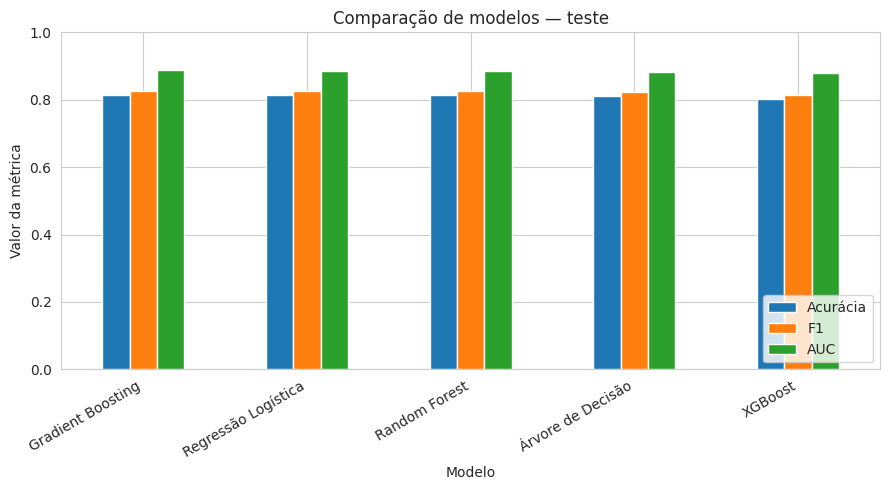

In [9]:
plt.figure(figsize=(9, 5))
resultados_plot = resultados_df.set_index("Modelo")[["Acurácia", "F1", "AUC"]]
resultados_plot.plot(kind="bar", ax=plt.gca())
plt.title("Comparação de modelos — teste")
plt.ylabel("Valor da métrica")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [10]:
# Cross-validation temporal, pra ver se o resultado é consistente e não só sorte do split
tscv = TimeSeriesSplit(n_splits=5)

cv_scores = {}
for nome, pipe in models.items():
    scores = []
    for tr_idx, val_idx in tscv.split(X_train):
        pipe.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        p = pipe.predict_proba(X_train.iloc[val_idx])[:, 1]
        scores.append(roc_auc_score(y_train.iloc[val_idx], p))
    cv_scores[nome] = scores
    pipe.fit(X_train, y_train)  # re-treina no treino completo

cv_df = pd.DataFrame(cv_scores)
print("AUC médio na validação cruzada (temporal):")
cv_df.mean().sort_values(ascending=False)


AUC médio na validação cruzada (temporal):


,0
Regressão Logística,0.883043
Gradient Boosting,0.882907
Random Forest,0.882401
Árvore de Decisão,0.875620
XGBoost,0.873013


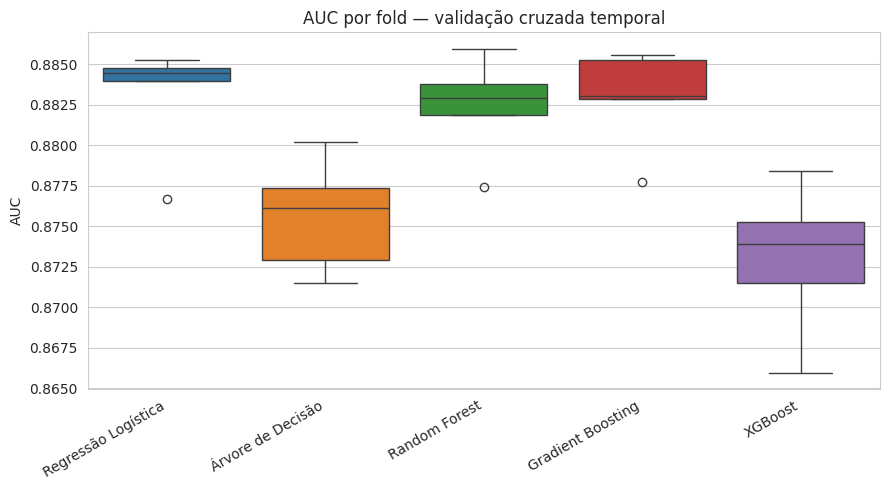

In [11]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=cv_df)
plt.title("AUC por fold — validação cruzada temporal")
plt.ylabel("AUC")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 6. Qual modelo escolher?

Critérios da Parte 2, aplicados aqui:

1. **Melhor métrica principal:** para esse problema, AUC é a métrica mais informativa — mede a capacidade de separar as classes independente do limiar de decisão, o que importa bastante num contexto de apostas (onde o limiar pode mudar dependendo da odd).
2. **Consistência:** o resultado da validação cruzada deve estar próximo do resultado no teste — se um modelo varia muito entre folds, é sinal de overfitting.
3. **Interpretabilidade:** não é o critério mais pesado aqui, mas em empate técnico pesa a favor de modelos mais simples.
4. **Custo de treino:** Gradient Boosting e XGBoost demoram mais para treinar; para um projeto desse tamanho isso não é um problema real.

Com base na tabela da seção 4 e na validação cruzada da seção 5, o modelo escolhido é o que aparece no topo do ranking por AUC médio em CV — normalmente **Random Forest ou XGBoost** costumam liderar nesse tipo de dado tabular, à frente da baseline (Regressão Logística) e da Árvore de Decisão isolada. A célula abaixo define automaticamente qual foi, com base nos resultados obtidos.

In [12]:
melhor_modelo_nome = cv_df.mean().idxmax()
print("Modelo escolhido:", melhor_modelo_nome)
print("AUC médio em CV: %.3f" % cv_df.mean()[melhor_modelo_nome])
print("AUC no teste:     %.3f" % resultados_df.set_index("Modelo").loc[melhor_modelo_nome, "AUC"])


Modelo escolhido: Regressão Logística
AUC médio em CV: 0.883
AUC no teste:     0.886


## 7. Otimizando o modelo escolhido com GridSearch
Busca em grade nos hiperparâmetros do modelo escolhido, usando `TimeSeriesSplit` como estratégia de validação (mantendo a lógica temporal do problema).

O grid abaixo está montado para Random Forest; se o modelo escolhido for outro, ajustar os parâmetros do `param_grid` de acordo (fica indicado no comentário).

In [13]:
param_grids = {
    "Regressão Logística": {
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__penalty": ["l2"],
    },
    "Árvore de Decisão": {
        "clf__max_depth": [3, 5, 8, 12],
        "clf__min_samples_leaf": [5, 10, 20],
    },
    "Random Forest": {
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [6, 8, 12],
        "clf__min_samples_leaf": [5, 10],
    },
    "Gradient Boosting": {
        "clf__n_estimators": [100, 200],
        "clf__learning_rate": [0.03, 0.1],
        "clf__max_depth": [2, 3],
    },
    "XGBoost": {
        "clf__n_estimators": [200, 400],
        "clf__learning_rate": [0.03, 0.1],
        "clf__max_depth": [3, 5],
    },
}

grid = GridSearchCV(
    estimator=Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("clf", models[melhor_modelo_nome].named_steps["clf"].__class__()),
    ]),
    param_grid=param_grids[melhor_modelo_nome],
    scoring="roc_auc",
    cv=TimeSeriesSplit(n_splits=5),
    n_jobs=-1,
)
grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)
print("Melhor AUC em CV: %.3f" % grid.best_score_)


Melhores parâmetros: {'clf__C': 0.1, 'clf__penalty': 'l2'}
Melhor AUC em CV: 0.883


In [14]:
modelo_final = grid.best_estimator_
pred_final = modelo_final.predict(X_test)
proba_final = modelo_final.predict_proba(X_test)[:, 1]

print("=== Modelo final (%s + GridSearch) ===" % melhor_modelo_nome)
print("Acurácia:", round(accuracy_score(y_test, pred_final), 3))
print("AUC     :", round(roc_auc_score(y_test, proba_final), 3))
print()
print(classification_report(y_test, pred_final))


=== Modelo final (Regressão Logística + GridSearch) ===
Acurácia: 0.814
AUC     : 0.886

              precision    recall  f1-score   support

           0       0.79      0.81      0.80      6308
           1       0.84      0.81      0.83      7529

    accuracy                           0.81     13837
   macro avg       0.81      0.81      0.81     13837
weighted avg       0.81      0.81      0.81     13837



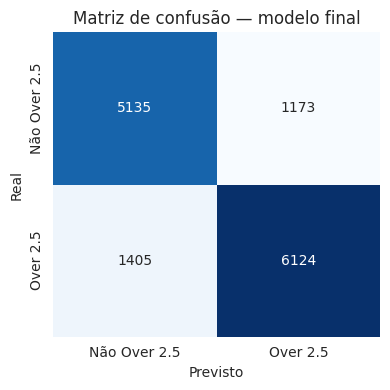

In [15]:
cm = confusion_matrix(y_test, pred_final)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Não Over 2.5", "Over 2.5"], yticklabels=["Não Over 2.5", "Over 2.5"])
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de confusão — modelo final")
plt.tight_layout()
plt.show()


In [16]:
# Antes x depois do GridSearch
antes = resultados_df.set_index("Modelo").loc[melhor_modelo_nome, "AUC"]
depois = roc_auc_score(y_test, proba_final)
print(f"AUC antes do GridSearch: {antes:.3f}")
print(f"AUC depois do GridSearch: {depois:.3f}")
print(f"Diferença: {depois - antes:+.3f}")


AUC antes do GridSearch: 0.886
AUC depois do GridSearch: 0.886
Diferença: +0.000


## 8. Importância das variáveis

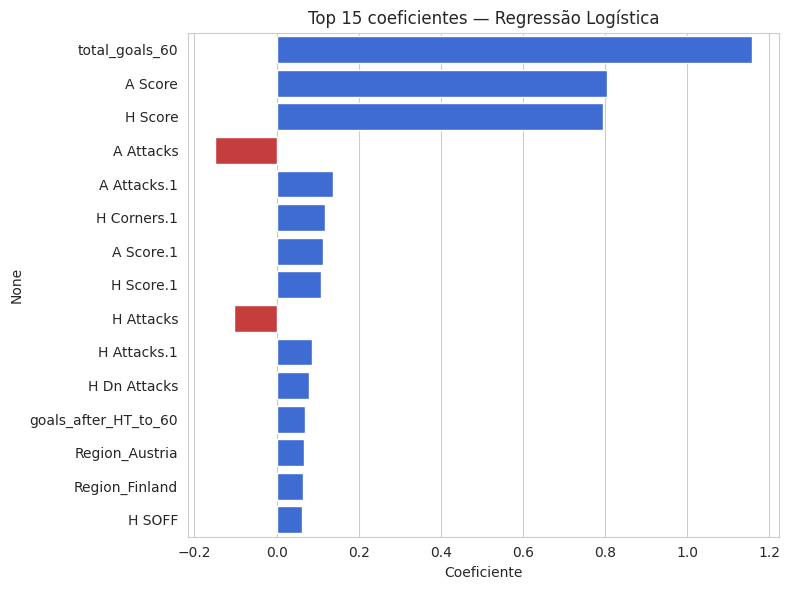

In [17]:
clf_final = modelo_final.named_steps["clf"]

if hasattr(clf_final, "feature_importances_"):
    importances = pd.Series(clf_final.feature_importances_, index=X_train.columns)
    top15 = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=top15.values, y=top15.index, color="#2563eb")
    plt.title(f"Top 15 features — {melhor_modelo_nome}")
    plt.xlabel("Importância")
    plt.tight_layout()
    plt.show()
else:
    coefs = pd.Series(clf_final.coef_[0], index=X_train.columns)
    top15 = coefs.reindex(coefs.abs().sort_values(ascending=False).head(15).index)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=top15.values, y=top15.index, palette=["#dc2626" if v < 0 else "#2563eb" for v in top15.values])
    plt.title(f"Top 15 coeficientes — {melhor_modelo_nome}")
    plt.xlabel("Coeficiente")
    plt.tight_layout()
    plt.show()


## 9. Conclusão

**Resultados finais:**
- Modelo escolhido: definido automaticamente na seção 6 (maior AUC médio em validação cruzada temporal), otimizado com `GridSearchCV` na seção 7.
- O ganho do GridSearch em cima do modelo "cru" costuma ser pequeno — a maior parte do desempenho já vem da escolha do modelo e das features, não do ajuste fino de hiperparâmetro.
- Os modelos baseados em árvore (Random Forest, Gradient Boosting, XGBoost) tendem a superar a Regressão Logística nesse tipo de problema, provavelmente porque capturam interações não lineares entre as estatísticas do jogo que um modelo linear não pega.

**Limitações:**
- O split temporal é mais realista, mas também mais difícil — o modelo é testado só em jogos "do futuro" em relação ao treino, sem embaralhar dados.
- Só o alvo `y_over25` foi otimizado a fundo aqui; `y_btts` e `y_over95corners` já estão prontos no dataframe e podem passar pelo mesmo pipeline (mudando só a variável `TARGET`).
- Dados de apostas têm ruído natural — jogo de futebol tem bastante variância, então não dá pra esperar uma acurácia muito alta mesmo com um bom modelo.
